# KuaiRand-1K 全量数据概览

本 Notebook 对 KuaiRand-1K 做第一轮 EDA：

- 文件规模、字段和原始样例；
- 标准曝光与随机曝光的日期、场景和反馈分布；
- 用户、视频基础特征和视频统计特征的数据质量；
- 推荐的时间划分及 DeepFM、DCN、DIN、MMoE 数据使用方案。

> 大 CSV 全部分块扫描。默认遍历完整的约 4.3GB 数据，但不会一次性加载到内存。首次运行耗时取决于磁盘速度。

In [1]:
from collections import Counter, defaultdict
from pathlib import Path
import gc
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")
plt.style.use("seaborn-v0_8-whitegrid")

RANDOM_SEED = 2026
CHUNK_SIZE = 400_000
SAMPLE_PER_CHUNK = 2_000

def find_project_root(start: Path) -> Path:
    for path in [start.resolve(), *start.resolve().parents]:
        if (path / "data" / "KuaiRand-1K" / "data").exists():
            return path
    raise FileNotFoundError("未找到 data/KuaiRand-1K/data。")

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "data" / "KuaiRand-1K" / "data"
FILE_MAP = {
    "standard_early": DATA_DIR / "log_standard_4_08_to_4_21_1k.csv",
    "standard_late": DATA_DIR / "log_standard_4_22_to_5_08_1k.csv",
    "random": DATA_DIR / "log_random_4_22_to_5_08_1k.csv",
    "users": DATA_DIR / "user_features_1k.csv",
    "video_basic": DATA_DIR / "video_features_basic_1k.csv",
    "video_statistic": DATA_DIR / "video_features_statistic_1k.csv",
}
print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DATA_DIR:    {DATA_DIR}")

Matplotlib is building the font cache; this may take a moment.


PROJECT_ROOT: /Users/peihs/Desktop/KuaiRankLab
DATA_DIR:    /Users/peihs/Desktop/KuaiRankLab/data/KuaiRand-1K/data


## 1. 文件、字段与样例

In [2]:
def human_size(num_bytes: int) -> str:
    size = float(num_bytes)
    for unit in ["B", "KB", "MB", "GB", "TB"]:
        if size < 1024 or unit == "TB":
            return f"{size:.2f} {unit}"
        size /= 1024

inventory = []
for key, path in FILE_MAP.items():
    columns = pd.read_csv(path, nrows=0).columns.tolist()
    inventory.append({
        "key": key, "file": path.name,
        "size": human_size(path.stat().st_size),
        "columns": len(columns),
        "column_names": ", ".join(columns),
    })
display(pd.DataFrame(inventory))

for key, path in FILE_MAP.items():
    print(f"\n[{key}] {path.name}")
    display(pd.read_csv(path, nrows=3))

,key,file,size,columns,column_names
0,standard_early,log_standard_4_08_to_4_21_1k.csv,356.36 MB,19,"user_id, video_id, date, hourmin, time_ms, is_..."
1,standard_late,log_standard_4_22_to_5_08_1k.csv,469.50 MB,19,"user_id, video_id, date, hourmin, time_ms, is_..."
2,random,log_random_4_22_to_5_08_1k.csv,2.94 MB,19,"user_id, video_id, date, hourmin, time_ms, is_..."
3,users,user_features_1k.csv,124.54 KB,31,"user_id, user_active_degree, is_lowactive_peri..."
4,video_basic,video_features_basic_1k.csv,359.43 MB,12,"video_id, author_id, video_type, upload_dt, up..."
5,video_statistic,video_features_statistic_1k.csv,3.14 GB,52,"video_id, counts, show_cnt, show_user_num, pla..."



[standard_early] log_standard_4_08_to_4_21_1k.csv


,user_id,video_id,date,hourmin,time_ms,is_click,is_like,is_follow,is_comment,is_forward,is_hate,long_view,play_time_ms,duration_ms,profile_stay_time,comment_stay_time,is_profile_enter,is_rand,tab
0,0,4354972,20220409,900,1649467982289,0,0,0,0,0,0,0,0,70100,0,0,0,0,0
1,0,1329429,20220409,900,1649467982289,0,0,0,0,0,0,0,0,51422,0,0,0,0,0
2,0,346081,20220409,900,1649467982289,0,0,0,0,0,0,0,0,11696,0,0,0,0,0



[standard_late] log_standard_4_22_to_5_08_1k.csv


,user_id,video_id,date,hourmin,time_ms,is_click,is_like,is_follow,is_comment,is_forward,is_hate,long_view,play_time_ms,duration_ms,profile_stay_time,comment_stay_time,is_profile_enter,is_rand,tab
0,0,554434,20220422,500,1650575715200,0,0,0,0,0,0,0,3925,7833,0,0,1,0,1
1,0,1848093,20220422,500,1650575727466,0,0,0,0,0,0,0,0,106900,0,0,0,0,0
2,0,4226937,20220422,500,1650575727466,0,0,0,0,0,0,0,0,130533,0,0,0,0,0


...

,user_id,user_active_degree,is_lowactive_period,is_live_streamer,is_video_author,follow_user_num,follow_user_num_range,fans_user_num,fans_user_num_range,friend_user_num,friend_user_num_range,register_days,register_days_range,onehot_feat0,onehot_feat1,onehot_feat2,onehot_feat3,onehot_feat4,onehot_feat5,onehot_feat6,onehot_feat7,onehot_feat8,onehot_feat9,onehot_feat10,onehot_feat11,onehot_feat12,onehot_feat13,onehot_feat14,onehot_feat15,onehot_feat16,onehot_feat17
0,0,full_active,0,1,1,514,500+,150,"[100,1k)",34,"[30,60)",799,730+,1,1,29,949,1.000000,0,0,14,135,6,3,0,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
1,1,full_active,0,-124,1,457,"(250,500]",20,"[10,100)",3,"[1,5)",1474,730+,1,3,2,1160,4.000000,0,0,31,283,6,2,2,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
2,2,full_active,0,-124,1,8,"(0,10]",26,"[10,100)",3,"[1,5)",231,181-365,1,0,2,1176,2.000000,0,0,31,275,5,2,2,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000



[video_basic] video_features_basic_1k.csv


,video_id,author_id,video_type,upload_dt,upload_type,visible_status,video_duration,server_width,server_height,music_id,music_type,tag
0,0,7349781,NORMAL,2022-04-10,LongImport,0.000000,"87,433.000000",720.000000,"1,280.000000",9155697141,9.000000,39
1,1,2103883,NORMAL,2022-04-10,Kmovie,0.000000,"218,066.000000",720.000000,"1,280.000000",6355810746,9.000000,2
2,2,5067285,NORMAL,2022-04-09,ShortImport,0.000000,"9,233.000000",720.000000,"1,280.000000",6618412736,4.000000,1



[video_statistic] video_features_statistic_1k.csv


,video_id,counts,show_cnt,show_user_num,play_cnt,play_user_num,play_duration,complete_play_cnt,complete_play_user_num,valid_play_cnt,valid_play_user_num,long_time_play_cnt,long_time_play_user_num,short_time_play_cnt,short_time_play_user_num,play_progress,comment_stay_duration,like_cnt,like_user_num,click_like_cnt,double_click_cnt,cancel_like_cnt,cancel_like_user_num,comment_cnt,comment_user_num,direct_comment_cnt,reply_comment_cnt,delete_comment_cnt,delete_comment_user_num,comment_like_cnt,comment_like_user_num,follow_cnt,follow_user_num,cancel_follow_cnt,cancel_follow_user_num,share_cnt,share_user_num,download_cnt,download_user_num,report_cnt,report_user_num,reduce_similar_cnt,reduce_similar_user_num,collect_cnt,collect_user_num,cancel_collect_cnt,cancel_collect_user_num,direct_comment_user_num,reply_comment_user_num,share_all_cnt,share_all_user_num,outsite_share_all_cnt
0,0,102,"2,579.686275","2,308.323529",816.882353,713.176471,"27,679,151.656863",195.254902,183.098039,443.019608,414.431373,318.970588,299.333333,227.098039,206.372549,0.117407,"203,428.166667",6.470588,6.392157,2.921569,3.519608,0.696078,0.656863,0.196078,0.196078,0.156863,0.039216,0.019608,0.019608,0.039216,0.039216,0.843137,0.823529,0.519608,0.509804,0.058824,0.058824,0.019608,0.019608,0.000000,0.000000,0.960784,0.911765,0.901961,0.882353,0.235294,0.235294,0.156863,0.039216,0.117647,0.107843,0.078431
1,1,136,"4,027.992647","3,368.367647","2,116.250000","1,864.044118","85,921,520.705882",130.507353,125.941176,717.676471,669.316176,549.654412,518.102941,"1,071.007353",969.147059,0.064726,"797,810.272059",38.161765,37.345588,22.235294,15.867647,3.419118,2.852941,2.794118,2.345588,2.007353,0.786765,0.102941,0.095588,2.691176,1.477941,3.500000,3.492647,0.573529,0.573529,1.698529,1.477941,4.058824,3.977941,0.000000,0.000000,2.764706,2.279412,6.683824,6.470588,1.279412,1.176471,1.867647,0.551471,5.470588,4.963235,4.691176
2,2,91,666.703297,547.219780,425.681319,386.538462,"4,197,048.472527",80.208791,75.461538,95.725275,90.043956,79.868132,75.164835,264.395604,245.527473,0.238342,"54,158.384615",6.626374,6.582418,5.175824,1.439560,0.373626,0.351648,1.296703,1.208791,1.186813,0.109890,0.000000,0.000000,0.065934,0.065934,0.252747,0.252747,0.076923,0.076923,0.197802,0.175824,0.109890,0.109890,0.000000,0.000000,2.714286,2.670330,1.835165,1.791209,0.681319,0.659341,1.153846,0.054945,0.296703,0.274725,0.285714


## 2. 三份交互日志全量扫描

统计行数、用户和视频数、日期、每用户交互量、场景分布、标签正例率及每日样本。`is_click` 在不同页面上的业务含义可能不同，因此同时统计全场景和 `tab=1`。

In [3]:
LABEL_COLS = [
    "is_click", "is_like", "is_follow", "is_comment",
    "is_forward", "is_hate", "long_view", "is_profile_enter",
]
LOG_KEYS = ["standard_early", "standard_late", "random"]

def add_value_counts(counter: Counter, series: pd.Series) -> None:
    counter.update({int(k): int(v) for k, v in series.items()})

def scan_log(path: Path, chunksize: int = CHUNK_SIZE):
    rows = 0
    users, videos = set(), set()
    user_counts, tab_counts = Counter(), Counter()
    label_sums, null_counts = Counter(), Counter()
    daily_rows, daily_tab1_rows = Counter(), Counter()
    daily_users = defaultdict(set)
    daily_labels = defaultdict(Counter)
    daily_tab1_labels = defaultdict(Counter)
    label_samples = []
    rand_count = play_sum = duration_sum = play_ge_duration = 0

    for chunk_no, df in enumerate(pd.read_csv(path, chunksize=chunksize)):
        n = len(df)
        rows += n
        users.update(map(int, df.user_id.unique()))
        videos.update(map(int, df.video_id.unique()))
        add_value_counts(user_counts, df.user_id.value_counts())
        add_value_counts(tab_counts, df.tab.value_counts())
        rand_count += int(df.is_rand.sum())
        play_sum += int(df.play_time_ms.sum())
        duration_sum += int(df.duration_ms.sum())
        play_ge_duration += int((df.play_time_ms >= df.duration_ms).sum())
        null_counts.update({c: int(v) for c, v in df.isna().sum().items()})
        label_sums.update({c: int(df[c].sum()) for c in LABEL_COLS})

        for date_value, group in df.groupby("date", sort=False):
            date_value = int(date_value)
            tab1 = group[group.tab == 1]
            daily_rows[date_value] += len(group)
            daily_tab1_rows[date_value] += len(tab1)
            daily_users[date_value].update(map(int, group.user_id.unique()))
            daily_labels[date_value].update({c: int(group[c].sum()) for c in LABEL_COLS})
            daily_tab1_labels[date_value].update({c: int(tab1[c].sum()) for c in LABEL_COLS})

        label_samples.append(
            df[LABEL_COLS].sample(min(SAMPLE_PER_CHUNK, n), random_state=RANDOM_SEED + chunk_no)
        )

    per_user = pd.Series(user_counts, dtype="int64").reindex(range(1000), fill_value=0).sort_index()
    dates = sorted(daily_rows)
    daily = pd.DataFrame({
        "date": pd.to_datetime([str(d) for d in dates]),
        "rows": [daily_rows[d] for d in dates],
        "tab1_rows": [daily_tab1_rows[d] for d in dates],
        "active_users": [len(daily_users[d]) for d in dates],
    })
    for col in LABEL_COLS:
        daily[f"{col}_positive"] = [daily_labels[d][col] for d in dates]
        daily[f"tab1_{col}_positive"] = [daily_tab1_labels[d][col] for d in dates]

    summary = {
        "rows": rows, "unique_users": len(users), "unique_videos": len(videos),
        "date_min": int(min(daily_rows)), "date_max": int(max(daily_rows)),
        "per_user_min": int(per_user.min()),
        "per_user_median": float(per_user.median()),
        "per_user_max": int(per_user.max()),
        "is_rand_rate": rand_count / rows,
        "mean_play_time_ms": play_sum / rows,
        "mean_duration_ms": duration_sum / rows,
        "play_ge_duration_rate": play_ge_duration / rows,
    }
    rates = pd.Series({c: label_sums[c] / rows for c in LABEL_COLS})
    tabs = pd.Series(tab_counts, dtype="int64").sort_index()
    nulls = pd.Series(null_counts, dtype="int64").sort_values(ascending=False)
    sample = pd.concat(label_samples, ignore_index=True)
    del videos, label_samples
    gc.collect()
    return summary, daily, per_user, tabs, rates, nulls, sample

LOG_RESULTS = {}
for key in LOG_KEYS:
    print(f"Scanning {key}: {FILE_MAP[key].name}")
    LOG_RESULTS[key] = scan_log(FILE_MAP[key])
print("日志全量扫描完成。")

Scanning standard_early: log_standard_4_08_to_4_21_1k.csv
Scanning standard_late: log_standard_4_22_to_5_08_1k.csv
Scanning random: log_random_4_22_to_5_08_1k.csv
日志全量扫描完成。


,rows,unique_users,unique_videos,date_min,date_max,per_user_min,per_user_median,per_user_max,is_rand_rate,mean_play_time_ms,mean_duration_ms,play_ge_duration_rate
standard_early,"5,055,984.000000",983.000000,"2,119,510.000000","20,220,408.000000","20,220,421.000000",0.000000,"3,421.000000","49,242.000000",0.000000,"14,962.699409","72,614.546977",0.231436
standard_late,"6,657,061.000000","1,000.000000","2,664,050.000000","20,220,422.000000","20,220,508.000000",116.000000,"4,751.500000","78,315.000000",0.000000,"14,659.310954","71,851.587981",0.230859
random,"43,028.000000","1,000.000000","7,388.000000","20,220,422.000000","20,220,508.000000",10.000000,22.000000,650.000000,1.000000,"6,725.488054","105,319.058125",0.062099


,is_click,is_like,is_follow,is_comment,is_forward,is_hate,long_view,is_profile_enter
standard_early,37.9339%,1.5053%,0.1132%,0.2451%,0.0784%,0.1726%,26.3463%,1.7852%
standard_late,37.7330%,1.6033%,0.0853%,0.2814%,0.0785%,0.0320%,26.0986%,1.7941%
random,17.4119%,0.5555%,0.0186%,0.0302%,0.0651%,0.0813%,8.4155%,0.4602%


场景样本量：


,standard_early,standard_late,random
0,1066194,1341158,0
1,3286302,4431299,42636
2,183556,218737,73
3,19720,17698,0
4,402534,492851,0
5,6991,9433,0
6,66045,117358,0
7,1696,2137,0
8,7712,9718,0
9,1132,779,0


standard_early 缺失字段： 无
standard_late 缺失字段： 无
random 缺失字段： 无


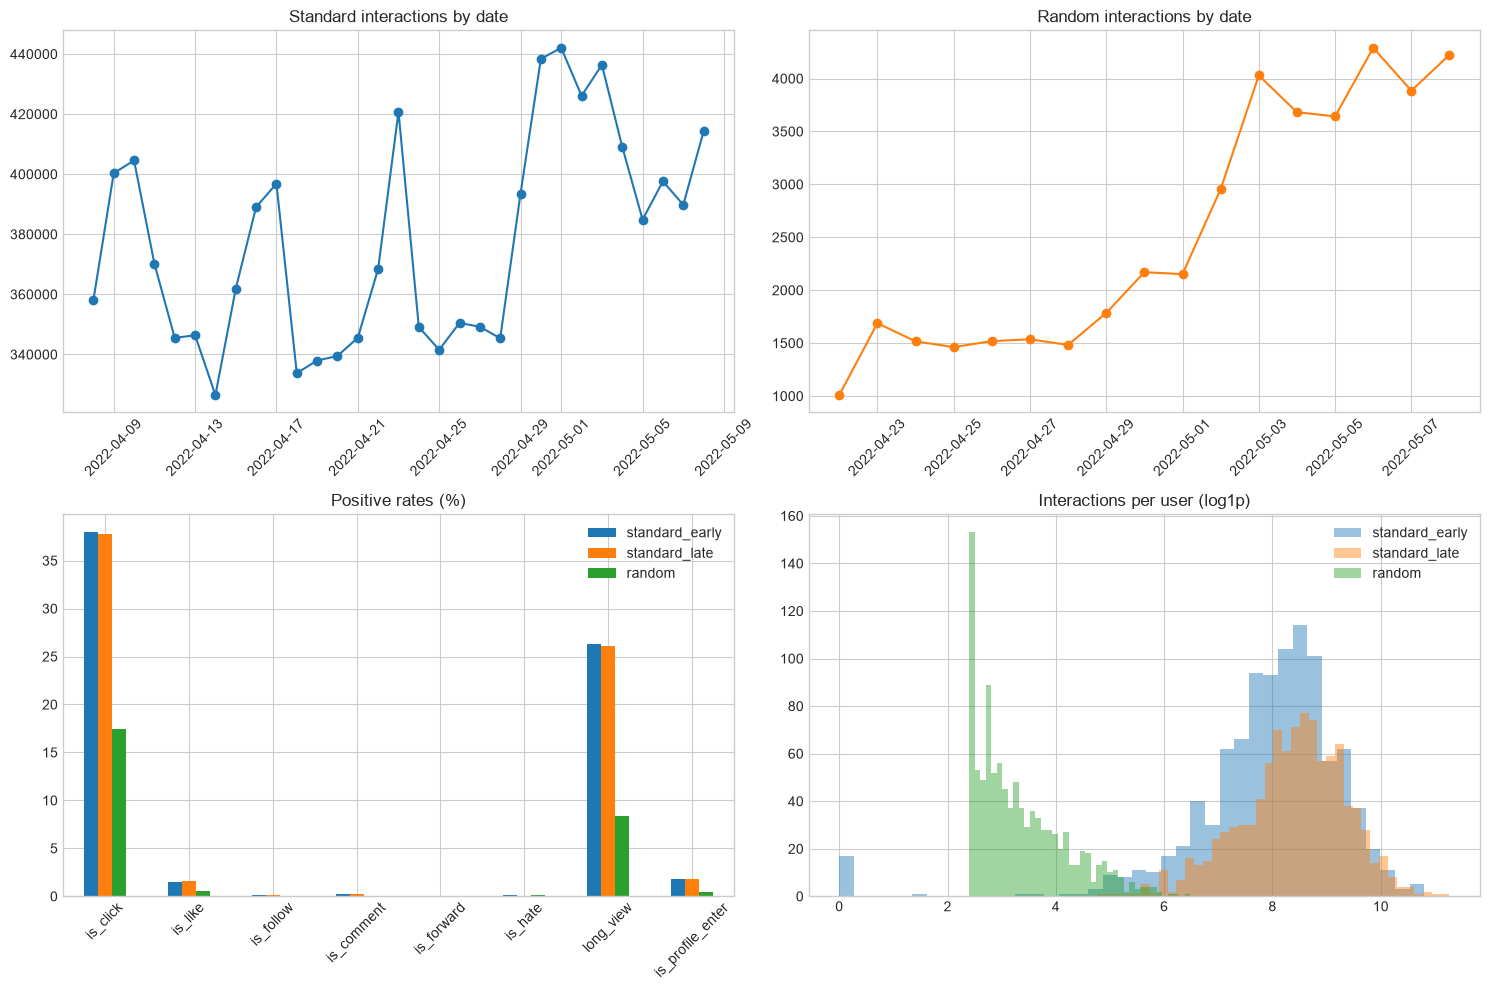

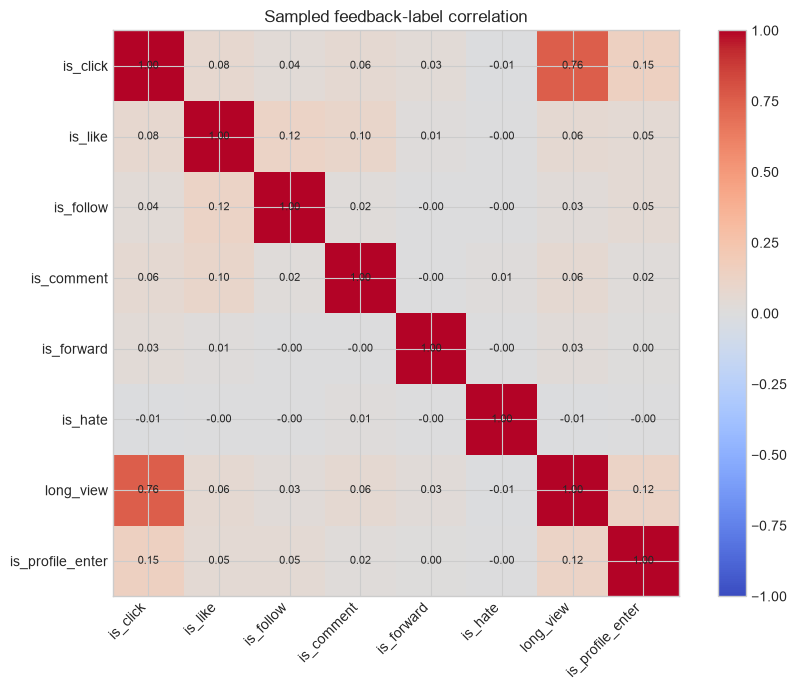

In [4]:
log_summary = pd.DataFrame({k: LOG_RESULTS[k][0] for k in LOG_KEYS}).T
label_rates = pd.DataFrame({k: LOG_RESULTS[k][4] for k in LOG_KEYS}).T
tab_counts = pd.DataFrame({k: LOG_RESULTS[k][3] for k in LOG_KEYS}).fillna(0).astype(int)
display(log_summary)
display(label_rates.style.format("{:.4%}"))
print("场景样本量：")
display(tab_counts)

for key in LOG_KEYS:
    missing = LOG_RESULTS[key][5]
    missing = missing[missing > 0]
    print(f"{key} 缺失字段：", "无" if missing.empty else missing.to_dict())

standard_daily = pd.concat([LOG_RESULTS["standard_early"][1], LOG_RESULTS["standard_late"][1]])
standard_daily = standard_daily.groupby("date", as_index=False).sum(numeric_only=True)
random_daily = LOG_RESULTS["random"][1]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes[0, 0].plot(standard_daily.date, standard_daily.rows, marker="o")
axes[0, 0].set_title("Standard interactions by date")
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 1].plot(random_daily.date, random_daily.rows, marker="o", color="tab:orange")
axes[0, 1].set_title("Random interactions by date")
axes[0, 1].tick_params(axis="x", rotation=45)
(label_rates * 100).T.plot(kind="bar", ax=axes[1, 0])
axes[1, 0].set_title("Positive rates (%)")
axes[1, 0].tick_params(axis="x", rotation=45)
for key in LOG_KEYS:
    axes[1, 1].hist(np.log1p(LOG_RESULTS[key][2]), bins=40, alpha=0.45, label=key)
axes[1, 1].set_title("Interactions per user (log1p)")
axes[1, 1].legend()
plt.tight_layout()
plt.show()

sampled_labels = pd.concat([LOG_RESULTS[k][6] for k in LOG_KEYS], ignore_index=True)
corr = sampled_labels.corr()
fig, ax = plt.subplots(figsize=(9, 7))
image = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(LABEL_COLS)), LABEL_COLS, rotation=45, ha="right")
ax.set_yticks(range(len(LABEL_COLS)), LABEL_COLS)
for i in range(len(LABEL_COLS)):
    for j in range(len(LABEL_COLS)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=ax)
ax.set_title("Sampled feedback-label correlation")
plt.tight_layout()
plt.show()

## 3. 用户特征

用户表只有 1,000 行，直接全量加载。重点检查缺失值、`-124` 哨兵值和类别基数。

shape=(1000, 31), unique_id=1000, duplicated_id=0


,missing_count,missing_rate
onehot_feat4,33,3.30%
onehot_feat12,33,3.30%
onehot_feat13,33,3.30%
onehot_feat14,33,3.30%
onehot_feat15,33,3.30%
onehot_feat16,33,3.30%
onehot_feat17,33,3.30%


-124 哨兵值： {'is_live_streamer': 782}


,nunique
user_id,1000
register_days,798
follow_user_num,532
onehot_feat3,394
fans_user_num,379
onehot_feat8,283
friend_user_num,264
onehot_feat7,37
onehot_feat2,23
onehot_feat4,14


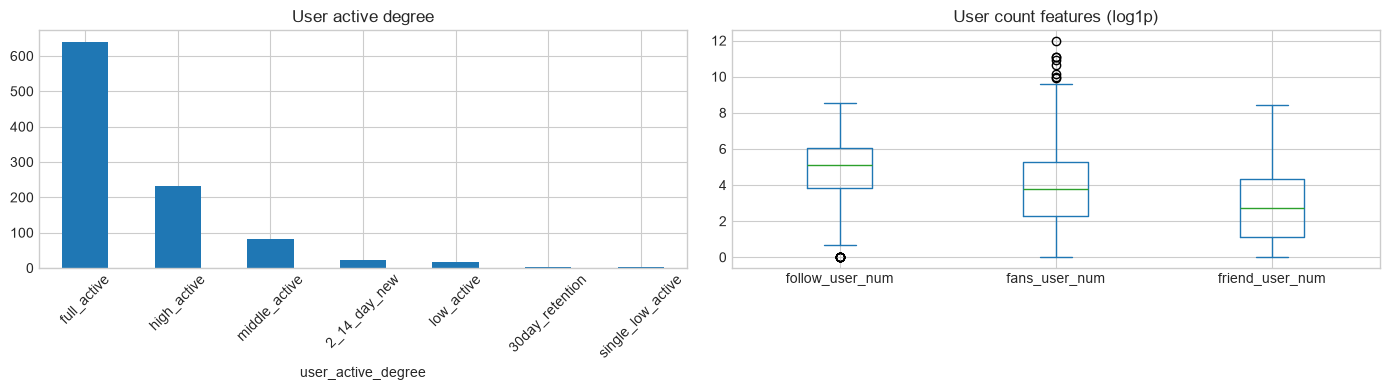

In [5]:
users = pd.read_csv(FILE_MAP["users"])
print(f"shape={users.shape}, unique_id={users.user_id.nunique()}, duplicated_id={users.user_id.duplicated().sum()}")
user_missing = pd.DataFrame({
    "missing_count": users.isna().sum(),
    "missing_rate": users.isna().mean(),
}).query("missing_count > 0").sort_values("missing_rate", ascending=False)
sentinel = {
    c: int((users[c] == -124).sum())
    for c in users.select_dtypes(include=np.number).columns
    if (users[c] == -124).any()
}
display(user_missing.style.format({"missing_rate": "{:.2%}"}))
print("-124 哨兵值：", sentinel)
display(users.nunique(dropna=False).sort_values(ascending=False).rename("nunique").to_frame())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
users.user_active_degree.value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("User active degree")
axes[0].tick_params(axis="x", rotation=45)
np.log1p(users[["follow_user_num", "fans_user_num", "friend_user_num"]].clip(lower=0)).plot(kind="box", ax=axes[1])
axes[1].set_title("User count features (log1p)")
plt.tight_layout()
plt.show()

## 4. 视频基础特征全量扫描

全量统计缺失率和类别频数；连续特征分位数及绘图采用分块抽样。

Scanning video basic features...


,value
rows,4371868
id_min,0
id_max,4371899
id_monotonic,True
duplicate_ids,0
upload_min,2018-05-20
upload_max,2022-05-08


,missing_count,missing_rate
video_duration,573057,13.11%
tag,137484,3.14%
music_type,59952,1.37%
upload_dt,58,0.00%
server_width,7,0.00%
server_height,7,0.00%
visible_status,5,0.00%


,video_duration,server_width,server_height
count,"19,049.000000","22,000.000000","22,000.000000"
mean,"75,632.436401",812.905727,"1,234.745182"
std,"102,147.717880",261.708051,306.323416
min,"3,000.000000",156.000000,95.000000
50%,"35,101.000000",720.000000,"1,280.000000"
90%,"194,100.000000","1,152.100000","1,440.000000"
95%,"271,850.800000","1,280.000000","1,440.000000"
99%,"494,559.560000","1,714.140000","2,160.000000"
max,"1,268,640.000000","4,096.000000","4,096.000000"


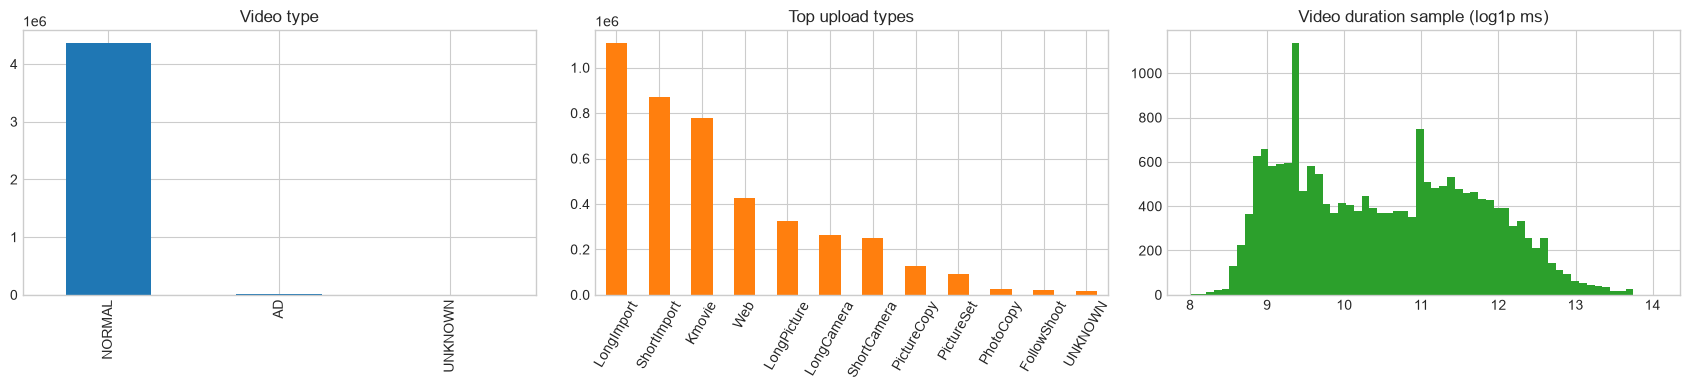

In [6]:
BASIC_CAT_COLS = ["video_type", "upload_type", "visible_status", "music_type"]

def scan_video_basic(path: Path):
    rows, previous_id, duplicates = 0, None, 0
    id_min, id_max, monotonic = None, None, True
    nulls = Counter()
    categories = {c: Counter() for c in BASIC_CAT_COLS}
    samples = []
    upload_min, upload_max = None, None
    for chunk_no, df in enumerate(pd.read_csv(path, chunksize=CHUNK_SIZE)):
        rows += len(df)
        ids = df.video_id.to_numpy()
        id_min = int(ids.min()) if id_min is None else min(id_min, int(ids.min()))
        id_max = int(ids.max()) if id_max is None else max(id_max, int(ids.max()))
        monotonic &= bool(np.all(ids[1:] >= ids[:-1]))
        duplicates += int(np.sum(ids[1:] == ids[:-1]))
        if previous_id is not None:
            monotonic &= previous_id <= int(ids[0])
            duplicates += int(previous_id == int(ids[0]))
        previous_id = int(ids[-1])
        nulls.update({c: int(v) for c, v in df.isna().sum().items()})
        for col in BASIC_CAT_COLS:
            categories[col].update({str(k): int(v) for k, v in df[col].value_counts(dropna=False).items()})
        dates = df.upload_dt.dropna()
        if not dates.empty:
            upload_min = dates.min() if upload_min is None else min(upload_min, dates.min())
            upload_max = dates.max() if upload_max is None else max(upload_max, dates.max())
        samples.append(df.sample(min(SAMPLE_PER_CHUNK, len(df)), random_state=RANDOM_SEED + chunk_no))
    return {
        "rows": rows, "id_min": id_min, "id_max": id_max,
        "id_monotonic": monotonic, "duplicate_ids": duplicates,
        "upload_min": upload_min, "upload_max": upload_max,
        "nulls": pd.Series(nulls, dtype="int64"),
        "categories": categories, "sample": pd.concat(samples, ignore_index=True),
    }

print("Scanning video basic features...")
BASIC = scan_video_basic(FILE_MAP["video_basic"])
display(pd.Series({k: BASIC[k] for k in ["rows", "id_min", "id_max", "id_monotonic", "duplicate_ids", "upload_min", "upload_max"]}, name="value").to_frame())
basic_missing = pd.DataFrame({
    "missing_count": BASIC["nulls"],
    "missing_rate": BASIC["nulls"] / BASIC["rows"],
}).query("missing_count > 0").sort_values("missing_rate", ascending=False)
display(basic_missing.style.format({"missing_rate": "{:.2%}"}))
display(BASIC["sample"][["video_duration", "server_width", "server_height"]].describe(percentiles=[.5, .9, .95, .99]))

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
pd.Series(BASIC["categories"]["video_type"]).sort_values(ascending=False).plot(kind="bar", ax=axes[0])
axes[0].set_title("Video type")
pd.Series(BASIC["categories"]["upload_type"]).sort_values(ascending=False).head(12).plot(kind="bar", ax=axes[1], color="tab:orange")
axes[1].set_title("Top upload types")
axes[1].tick_params(axis="x", rotation=60)
duration = BASIC["sample"].video_duration.dropna().clip(lower=0)
axes[2].hist(np.log1p(duration), bins=60, color="tab:green")
axes[2].set_title("Video duration sample (log1p ms)")
plt.tight_layout()
plt.show()

## 5. 视频统计特征全量扫描

这是最大的 CSV（约 3.1GB）。完整统计行数、缺失和零值比例；分位数与图形采用抽样。

> 这些字段是整个月的聚合统计，可能包含预测时刻之后的信息。严格时间实验中先不要使用，后续单独作为潜在泄漏特征的消融实验。

Scanning video statistic features...


,value
rows,4371868
columns,52
feature_columns,51
id_min,0
id_max,4371899
id_monotonic,True
duplicate_ids,0
missing_values,0


,zero_rate
report_user_num,87.54%
report_cnt,87.54%
delete_comment_cnt,32.64%
delete_comment_user_num,32.64%
download_user_num,23.82%
download_cnt,23.82%
reply_comment_cnt,21.32%
reply_comment_user_num,21.32%
cancel_follow_user_num,16.98%
cancel_follow_cnt,16.98%


,count,mean,std,min,50%,90%,95%,99%,max
counts,"30,000.000000",66.696100,45.754143,2.000000,58.000000,136.000000,160.000000,185.000000,187.000000
show_cnt,"30,000.000000","6,051.369155","22,499.697021",2.200000,"1,550.077465","12,458.504237","23,488.193599","73,642.936528","1,244,144.111111"
play_cnt,"30,000.000000","4,601.823753","20,387.358624",0.315789,791.273148,"9,043.377532","18,559.233832","62,917.437315","1,341,969.944444"
play_duration,"30,000.000000","141,233,341.477566","794,658,394.461517","2,100.454545","13,610,939.929273","234,419,720.301020","519,152,643.457420","2,304,272,489.445317","60,301,432,223.215683"
valid_play_cnt,"30,000.000000","2,615.623599","12,055.852431",0.000000,371.795455,"5,021.776923","10,620.588597","38,552.580417","692,939.777778"
long_time_play_cnt,"30,000.000000","2,089.701284","10,083.480168",0.000000,251.254460,"3,873.556720","8,370.229945","31,869.009687","561,900.294118"
like_cnt,"30,000.000000",104.212583,492.685095,0.000000,13.578947,180.809378,406.330630,"1,631.343738","20,966.000000"
comment_cnt,"30,000.000000",10.171120,88.187084,0.000000,1.160000,13.976488,31.000000,142.005833,"6,782.055556"
follow_cnt,"30,000.000000",8.865383,43.388776,0.000000,1.112790,15.987767,34.656456,135.190479,"1,998.500000"
share_cnt,"30,000.000000",2.969613,23.143049,0.000000,0.250000,4.084223,9.838673,48.382840,"2,485.333333"


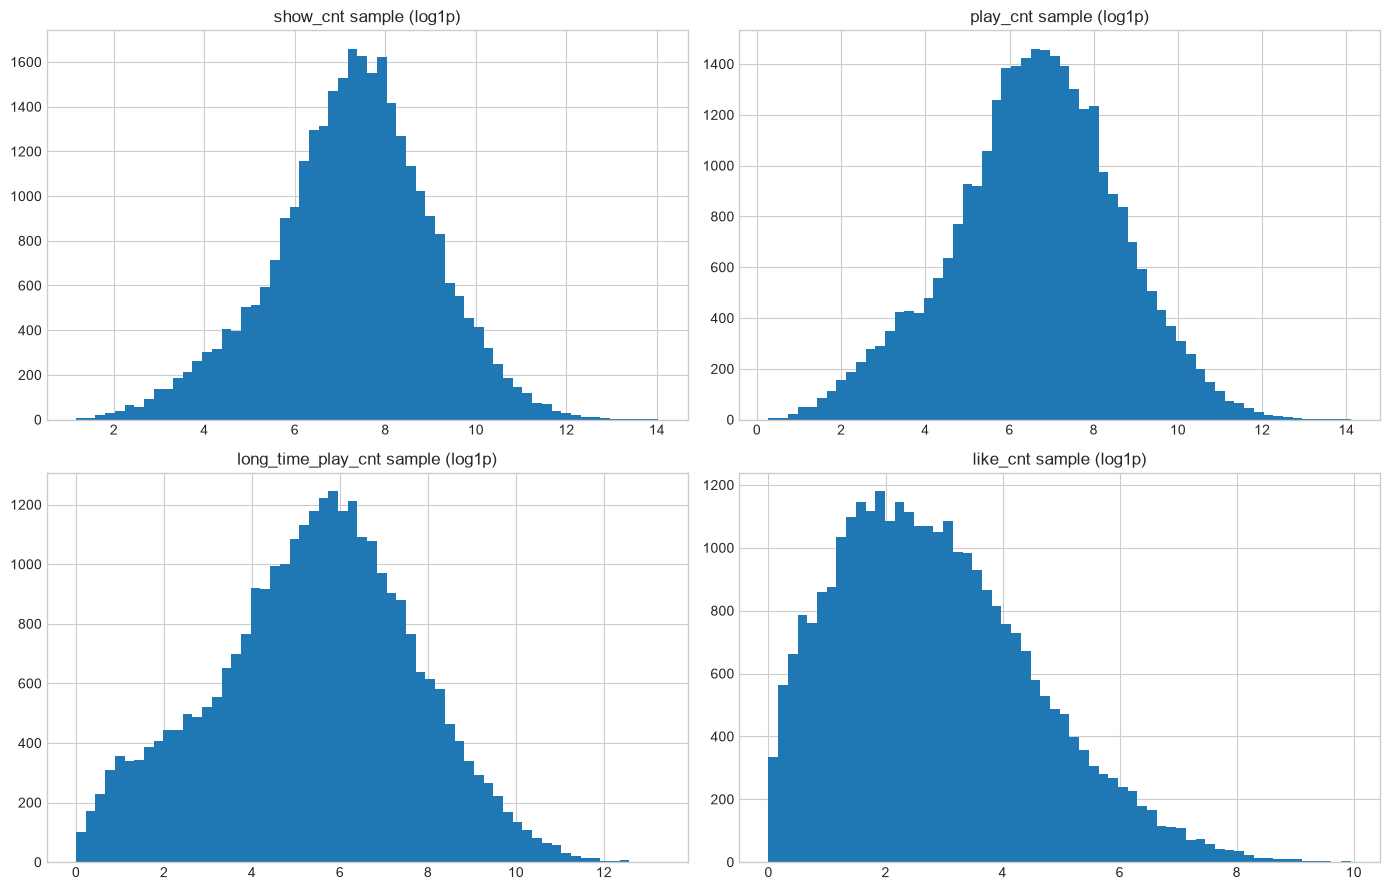

In [7]:
STAT_SAMPLE_COLS = [
    "counts", "show_cnt", "play_cnt", "play_duration", "valid_play_cnt",
    "long_time_play_cnt", "like_cnt", "comment_cnt", "follow_cnt",
    "share_cnt", "collect_cnt",
]

def scan_video_statistic(path: Path):
    rows, previous_id, duplicates = 0, None, 0
    id_min, id_max, monotonic, columns = None, None, True, None
    nulls, zeros, samples = Counter(), Counter(), []
    for chunk_no, df in enumerate(pd.read_csv(path, chunksize=150_000)):
        columns = df.columns.tolist() if columns is None else columns
        rows += len(df)
        ids = df.video_id.to_numpy()
        id_min = int(ids.min()) if id_min is None else min(id_min, int(ids.min()))
        id_max = int(ids.max()) if id_max is None else max(id_max, int(ids.max()))
        monotonic &= bool(np.all(ids[1:] >= ids[:-1]))
        duplicates += int(np.sum(ids[1:] == ids[:-1]))
        if previous_id is not None:
            monotonic &= previous_id <= int(ids[0])
            duplicates += int(previous_id == int(ids[0]))
        previous_id = int(ids[-1])
        nulls.update({c: int(v) for c, v in df.isna().sum().items()})
        zeros.update({c: int(v) for c, v in (df.drop(columns="video_id") == 0).sum().items()})
        samples.append(df[STAT_SAMPLE_COLS].sample(min(1_000, len(df)), random_state=RANDOM_SEED + chunk_no))
    return {
        "rows": rows, "columns": columns, "id_min": id_min, "id_max": id_max,
        "id_monotonic": monotonic, "duplicate_ids": duplicates,
        "nulls": pd.Series(nulls, dtype="int64"),
        "zeros": pd.Series(zeros, dtype="int64"),
        "sample": pd.concat(samples, ignore_index=True),
    }

print("Scanning video statistic features...")
STAT = scan_video_statistic(FILE_MAP["video_statistic"])
display(pd.Series({
    "rows": STAT["rows"], "columns": len(STAT["columns"]),
    "feature_columns": len(STAT["columns"]) - 1,
    "id_min": STAT["id_min"], "id_max": STAT["id_max"],
    "id_monotonic": STAT["id_monotonic"], "duplicate_ids": STAT["duplicate_ids"],
    "missing_values": int(STAT["nulls"].sum()),
}, name="value").to_frame())
zero_rate = (STAT["zeros"] / STAT["rows"]).sort_values(ascending=False)
display(zero_rate.head(20).rename("zero_rate").to_frame().style.format("{:.2%}"))
display(STAT["sample"].describe(percentiles=[.5, .9, .95, .99]).T)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.flat, ["show_cnt", "play_cnt", "long_time_play_cnt", "like_cnt"]):
    ax.hist(np.log1p(STAT["sample"][col].dropna().clip(lower=0)), bins=60)
    ax.set_title(f"{col} sample (log1p)")
plt.tight_layout()
plt.show()

## 6. 推荐的时间划分

标准日志负责训练、验证和常规测试；随机曝光只保留同日期窗口作为额外测试集。所有模型使用同一套样本划分。

,date_start,date_end,all_rows,tab1_rows
split,,,,
train,2022-04-08,2022-04-27,7235595,4730487
validation,2022-04-28,2022-05-02,2045412,1360773
standard_test,2022-05-03,2022-05-08,2432038,1626341
random_test,2022-05-03,2022-05-08,23752,23649


,tab1_is_click_rate,tab1_is_like_rate,tab1_is_follow_rate,tab1_is_comment_rate,tab1_is_forward_rate,tab1_is_hate_rate,tab1_long_view_rate,tab1_is_profile_enter_rate
split,,,,,,,,
train,44.7823%,1.8189%,0.1310%,0.2991%,0.0990%,0.0303%,31.9373%,2.0350%
validation,44.7529%,2.0765%,0.0943%,0.3420%,0.0941%,0.0362%,31.7297%,1.9963%
standard_test,43.6543%,2.1181%,0.1074%,0.3572%,0.1007%,0.0362%,30.8513%,1.9584%
random_test,18.0092%,0.5370%,0.0085%,0.0423%,0.0677%,0.0973%,8.7023%,0.4229%


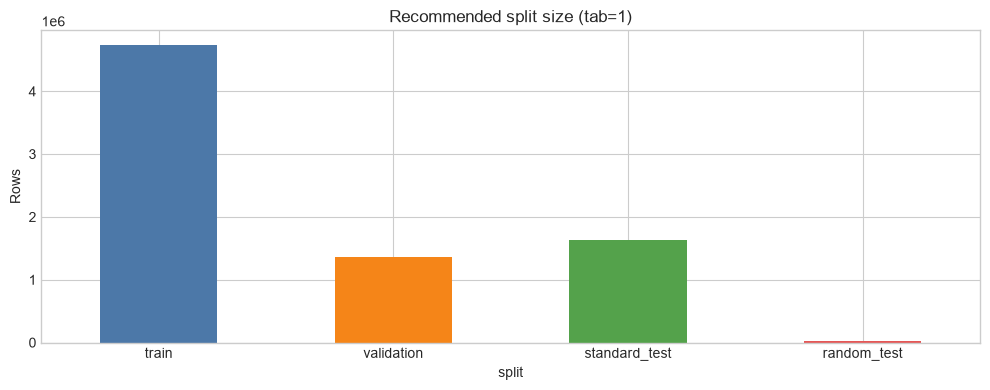

In [8]:
SPLITS = {
    "train": (pd.Timestamp("2022-04-08"), pd.Timestamp("2022-04-27"), standard_daily),
    "validation": (pd.Timestamp("2022-04-28"), pd.Timestamp("2022-05-02"), standard_daily),
    "standard_test": (pd.Timestamp("2022-05-03"), pd.Timestamp("2022-05-08"), standard_daily),
    "random_test": (pd.Timestamp("2022-05-03"), pd.Timestamp("2022-05-08"), random_daily),
}

split_rows = []
for name, (start, end, daily) in SPLITS.items():
    part = daily[daily.date.between(start, end)]
    tab1_rows = int(part.tab1_rows.sum())
    row = {
        "split": name, "date_start": start.date().isoformat(),
        "date_end": end.date().isoformat(),
        "all_rows": int(part.rows.sum()), "tab1_rows": tab1_rows,
    }
    for col in LABEL_COLS:
        row[f"tab1_{col}_rate"] = part[f"tab1_{col}_positive"].sum() / tab1_rows
    split_rows.append(row)

split_summary = pd.DataFrame(split_rows).set_index("split")
display(split_summary[["date_start", "date_end", "all_rows", "tab1_rows"]])
display(split_summary[[f"tab1_{c}_rate" for c in LABEL_COLS]].style.format("{:.4%}"))
ax = split_summary.tab1_rows.plot(kind="bar", figsize=(10, 4), color=["#4C78A8", "#F58518", "#54A24B", "#E45756"])
ax.set_title("Recommended split size (tab=1)")
ax.set_ylabel("Rows")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 7. 建模结论

### 第一版数据口径

- 使用 KuaiRand-1K，暂不使用 KuaiRand-Pure；
- 两份 `log_standard` 合并后按时间切分；
- 主实验先限制 `tab=1`，让 `is_click` 语义及随机测试场景更一致；
- `log_random` 不参与训练和调参，只作为 Random Test；
- 用户表和视频基础表作为侧信息；
- 视频统计表存在时间泄漏风险，严格实验暂不使用。

### 模型对应方式

- LR / DeepFM / DCN：先用 `is_click`，每条曝光已经是正负样本，不额外负采样；
- DIN：按 `user_id, time_ms` 排序，只允许使用当前时刻之前的点击或长播视频；
- MMoE：先使用 `is_click`、`long_view`、`is_like`、`is_profile_enter` 四个任务；
- 标准测试和随机测试分别报告 AUC、LogLoss、GAUC。

若要快速调试，应随机选择一批用户并保留完整时间序列，不能直接读取 CSV 前 N 行。